In [39]:
from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt
#Will be used for smoothing
from scipy.signal import savgol_filter, find_peaks

In [40]:
#Obtaining metadata for the video to calculate duration
cap = cv2.VideoCapture('Videos/vidssave.com How 5K running paces looks on a treadmill! 15 minutes 5K. 720P.mp4')
fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT)
duration = frame_count / fps
cap.release()

In [ ]:
model = YOLO("yolo26n-pose.pt")  # load a pretrained model (recommended for training)
#stream=True now allows us to process the video frame by frame
source = model(source='/Users/abhinavarora/Desktop/CadenceCV/Videos/vidssave.com How 5K running paces looks on a treadmill! 15 minutes 5K. 720P.mp4', show=False, conf=0.3, stream=True)
#Result for each frame
right_ankle_coords = []
left_ankle_coords = []
right_hip_coords = []
left_hip_coords = []
frames = []
#Frame index
i = 0
for result in source:
    #Obtaining the first person's keypoints from the video
    if len(result.keypoints) == 0:
        continue
    #Extracting essential keypoints based off indices according to the YOLOv8 documentation
    kpts = result.keypoints.xy[0]
    left_ankle = kpts[15]
    right_ankle = kpts[16]
    left_hip = kpts[11]
    right_hip = kpts[12]
    right_ankle_coords.append(right_ankle)
    left_ankle_coords.append(left_ankle)
    right_hip_coords.append(right_hip)
    left_hip_coords.append(left_hip)

    i += 1
    frames.append(i)

frames = np.array(frames)
right_ankle_coords = np.array(right_ankle_coords)
left_ankle_coords = np.array(left_ankle_coords)
right_hip_coords = np.array(right_hip_coords)
left_hip_coords = np.array(left_hip_coords)


(4.885321100917431, np.float32(27.786526))


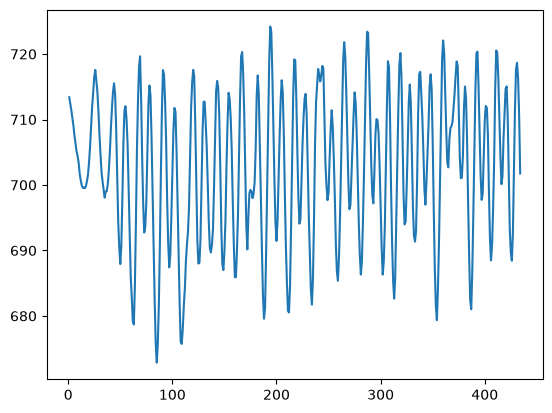

In [ ]:
#Returns vertical oscillations and cadence
def metrics():
    #Applying the savgol filter to smoothen it out and remove noise -> Easier for peak detection for cadence
    #find_peaks functions returns a tuple -> (arr, dict). dict must be discarded it isn't useful
    window_length = 9
    poly_order = 2
    right_ankle_coords_smooth = savgol_filter(right_ankle_coords[:,1], window_length=window_length, polyorder=poly_order)
    right_ankle_peaks, _ = find_peaks(right_ankle_coords_smooth, None, None, 8)

    left_ankle_coords_smooth = savgol_filter(left_ankle_coords[:,1], window_length=window_length, polyorder=poly_order)
    left_ankle_peaks, _ = find_peaks(left_ankle_coords_smooth, None, None, 8)

    #The idea is that each peak corresponds to a step since when stepping the foot has to come to the highest y-axis. So this applies for both 
    #feet so they're summed up. The total is averaged over the video duration
    cadence = (len(right_ankle_peaks) + len(left_ankle_peaks)) / duration

    right_hip_coords_smooth = savgol_filter(right_hip_coords[:,1], window_length=window_length, polyorder=poly_order)

    left_hip_coords_smooth = savgol_filter(left_hip_coords[:,1], window_length=window_length, polyorder=poly_order)

    #Finding the vertical oscillation is essentially checking the average oscillation during each stride. Strides can be determined via peaks
    #on the ankle position graphs -> Higher the peak number, lower it is on the screen
    #Finding the correct slice depending upon peaks in the ankle positioning
    def calculate_avg_hip_oscillations(peak_arr, smooth_hip_coords):
        #sum of hip_oscillations
        s = 0
        for i, peak in enumerate(peak_arr):
            if i + 1 < len(peak_arr):
                hip_frame_slice = smooth_hip_coords[peak: peak_arr[i+1] + 1]
                max_pos = max(hip_frame_slice)
                min_pos = min(hip_frame_slice)
                res = max_pos - min_pos
                s += res
        
        return s/len(peak_arr)
    
    left_hip_osc = calculate_avg_hip_oscillations(left_ankle_peaks, left_hip_coords_smooth)
    right_hip_osc = calculate_avg_hip_oscillations(right_ankle_peaks, right_hip_coords_smooth)
    avg_osc = (left_hip_osc + right_hip_osc)/2
    plt.plot(frames, right_hip_coords_smooth)
    return cadence, avg_osc

print(metrics())